In [ ]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [ ]:
def find_results_dir(start=Path.cwd()):
    """Find the autoencoder results directory from the repo root or a subdirectory."""
    relative = Path("Code/results/autoencoder/solubility")
    for parent in (start.resolve(), *start.resolve().parents):
        candidate = parent / relative
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find {relative} from {start.resolve()}")


def version_number(path):
    match = re.fullmatch(r"v(\d+)", path.name)
    return int(match.group(1)) if match else None


results_dir = find_results_dir()
version_dirs = [
    path for path in results_dir.iterdir()
    if path.is_dir() and version_number(path) is not None
]
selected_dirs = sorted(
    (path for path in version_dirs if version_number(path) == 5 or version_number(path) >= 21),
    key=version_number,
)

history_files = {}
for version_dir in selected_dirs:
    matches = sorted(version_dir.glob("*history.json"))
    if not matches:
        print(f"Skipping {version_dir.name}: no history JSON found")
        continue
    for index, history_path in enumerate(matches, start=1):
        label = version_dir.name if len(matches) == 1 else f"{version_dir.name} / {history_path.stem}"
        history_files[label] = history_path

print("Loaded history files:")
for label, path in history_files.items():
    role = "benchmark" if label == "v5" else "model"
    print(f"  {label:8s} ({role}): {path.relative_to(results_dir)}")

In [ ]:
required_columns = {"epoch", "train_loss", "val_loss", "train_accuracy", "val_accuracy"}
histories = {}

for label, path in history_files.items():
    with path.open() as file:
        payload = json.load(file)
    frame = pd.DataFrame(payload["epochs"])
    missing = required_columns.difference(frame.columns)
    if missing:
        raise KeyError(f"{path} is missing epoch metrics: {sorted(missing)}")
    histories[label] = frame.sort_values("epoch").reset_index(drop=True)

pd.DataFrame(
    {
        "epochs": {label: len(frame) for label, frame in histories.items()},
        "final_val_loss": {label: frame.iloc[-1]["val_loss"] for label, frame in histories.items()},
        "final_val_teacher_forced_accuracy": {
            label: frame.iloc[-1]["val_accuracy"] for label, frame in histories.items()
        },
    }
).rename_axis("version").round(4)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.tab10.colors

for color, (label, frame) in zip(colors, histories.items()):
    width = 2.8 if label == "v5" else 1.8
    ax.plot(frame["epoch"], frame["train_loss"], color=color, linestyle="--", alpha=0.75,
            linewidth=width, label=f"{label} train")
    ax.plot(frame["epoch"], frame["val_loss"], color=color, linewidth=width,
            label=f"{label} validation")

ax.set(title="Loss history: v5 benchmark vs. v21+", xlabel="Epoch", ylabel="Cross-entropy loss")
ax.legend(ncol=2, frameon=True)
fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for color, (label, frame) in zip(colors, histories.items()):
    width = 2.8 if label == "v5" else 1.8
    ax.plot(frame["epoch"], 100 * frame["train_accuracy"], color=color, linestyle="--", alpha=0.75,
            linewidth=width, label=f"{label} train")
    ax.plot(frame["epoch"], 100 * frame["val_accuracy"], color=color, linewidth=width,
            label=f"{label} validation")

ax.set(title="Teacher-forced accuracy history: v5 benchmark vs. v21+",
       xlabel="Epoch", ylabel="Token accuracy (%)", ylim=(0, 100))
ax.legend(ncol=2, frameon=True)
fig.tight_layout()
plt.show()

In [ ]:
import sys

import torch

project_root = results_dir.parents[3]
src_dir = project_root / "Code" / "src"
for import_path in (project_root, src_dir):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from testing.test_autoencoder import decode_token_ids, device, model_definition
from utils.dataloader import PAD_IDX, create_dataloader
from utils.hyperparameters import AutoencoderHyperparameters

checkpoint_root = project_root / "checkpoints" / "autoencoder" / "solubility"
checkpoint_dirs = sorted(
    (
        path for path in checkpoint_root.iterdir()
        if path.is_dir()
        and version_number(path) is not None
        and (version_number(path) == 5 or version_number(path) >= 21)
    ),
    key=version_number,
)
checkpoint_files = {}
for checkpoint_dir in checkpoint_dirs:
    matches = sorted(checkpoint_dir.glob("*.pt"))
    for checkpoint_path in matches:
        label = checkpoint_dir.name if len(matches) == 1 else f"{checkpoint_dir.name} / {checkpoint_path.stem}"
        checkpoint_files[label] = checkpoint_path

if not checkpoint_files:
    raise FileNotFoundError(f"No v5 or v21+ checkpoints found under {checkpoint_root}")

test_loader = create_dataloader(
    task="solubility",
    split="test",
    data_dir=project_root / "data" / "processed" / "peer",
    cache_dir=project_root / "data" / "processed" / "peer" / "cache",
    mode="autoencoder",
    batch_size=32,
    shuffle=False,
)

test_rows = []
for checkpoint_label, checkpoint_path in checkpoint_files.items():
    print(f"Evaluating {checkpoint_label}: {checkpoint_path.relative_to(project_root)}")
    inference_hyperparameters = AutoencoderHyperparameters()
    for training_only_name in ("grad_clip", "weight_decay", "validate_autoregressive"):
        delattr(inference_hyperparameters, training_only_name)
    model = model_definition("ae", inference_hyperparameters, checkpoint_path).eval()

    for decode_mode in ("teacher_forced",):
        example_index = 0
        with torch.inference_mode():
            for batch in test_loader:
                inputs = batch["input_ids"].to(device)
                lengths = batch["length"].to(device)
                targets = batch["target_ids"].to(device)[:, 1:]

                logits = model(inputs, decoder_input_ids=inputs[:, :-1], lengths=lengths)

                predictions = logits.argmax(dim=-1)
                for row_index, input_sequence in enumerate(batch["sequence"]):
                    target_ids = targets[row_index]
                    predicted_ids = predictions[row_index]
                    non_pad = target_ids != PAD_IDX
                    token_count = int(non_pad.sum().item())
                    correct_tokens = int((predicted_ids[non_pad] == target_ids[non_pad]).sum().item())
                    test_rows.append(
                        {
                            "checkpoint": checkpoint_label,
                            "decode_mode": decode_mode,
                            "example_index": example_index,
                            "target_sequence": decode_token_ids(target_ids.detach().cpu()),
                            "predicted_sequence": decode_token_ids(predicted_ids.detach().cpu()),
                            "target_length": len(str(input_sequence)),
                            "token_count": token_count,
                            "correct_tokens": correct_tokens,
                            "token_accuracy": correct_tokens / token_count if token_count else float("nan"),
                        }
                    )
                    example_index += 1

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

checkpoint_test_results = pd.DataFrame(test_rows)
display(checkpoint_test_results)
display(
    checkpoint_test_results.groupby(["checkpoint", "decode_mode"], observed=True)
    .agg(sequences=("example_index", "size"), accuracy=("token_accuracy", "mean"))
    .round(4)
)

,checkpoint,decode_mode,length_bucket,sequences,minimum_length,maximum_length,correct_tokens,tokens,mean_sequence_accuracy,token_accuracy
0,v21,autoregressive,short,502,34,159,38575,59077,0.6911,0.6530
1,v21,autoregressive,medium-short,501,160,260,28500,106116,0.2787,0.2686
2,v21,autoregressive,medium-long,500,261,379,24911,158424,0.1591,0.1572
3,v21,autoregressive,long,496,380,1200,27973,270744,0.1081,0.1033
4,v21,teacher_forced,short,502,34,159,56673,59077,0.9644,0.9593
5,v21,teacher_forced,medium-short,501,160,260,87228,106116,0.8295,0.8220
6,v21,teacher_forced,medium-long,500,261,379,101835,158424,0.6483,0.6428
7,v21,teacher_forced,long,496,380,1200,110505,270744,0.4366,0.4082
8,v22,autoregressive,short,502,34,159,37829,59077,0.6686,0.6403
9,v22,autoregressive,medium-short,501,160,260,34706,106116,0.3370,0.3271


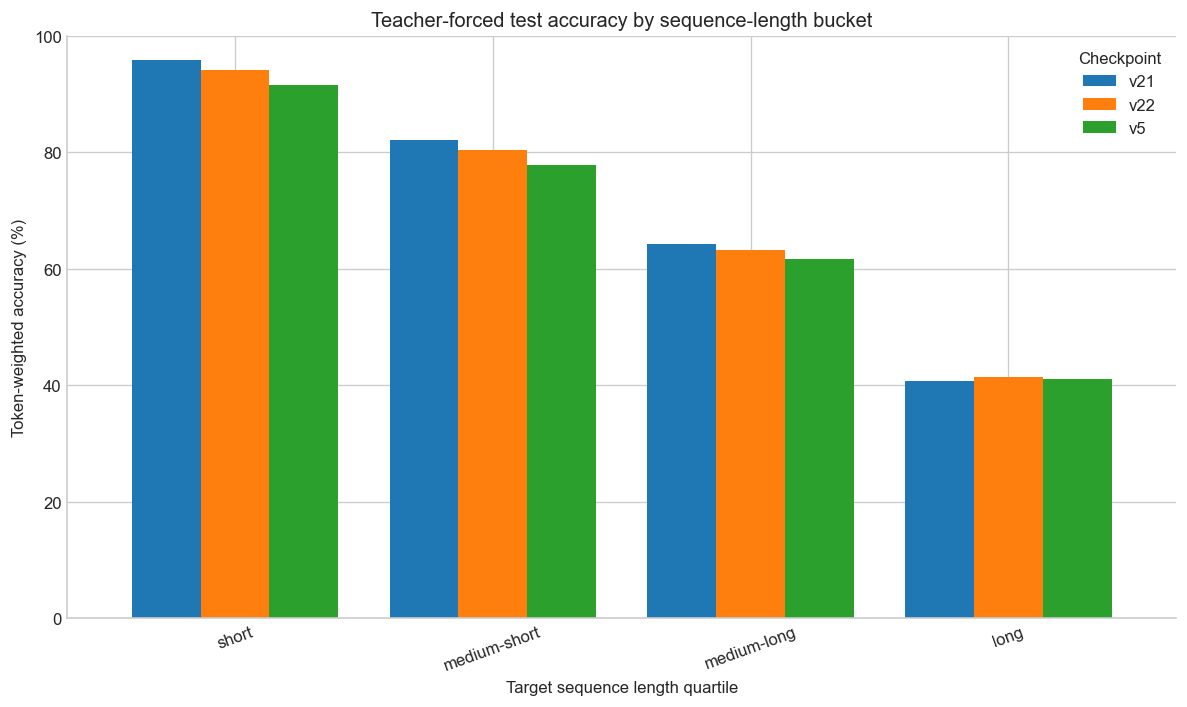

In [43]:
bucket_labels = ["short", "medium-short", "medium-long", "long"]
bucket_source = (
    checkpoint_test_results.query("decode_mode == 'teacher_forced'")
    .drop_duplicates("example_index")
    [["example_index", "target_length"]]
    .sort_values("example_index")
    .copy()
)
bucket_source["length_bucket"] = pd.qcut(
    bucket_source["target_length"],
    q=4,
    labels=bucket_labels,
    duplicates="drop",
)
checkpoint_test_results = checkpoint_test_results.drop(
    columns="length_bucket", errors="ignore"
).merge(
    bucket_source[["example_index", "length_bucket"]],
    on="example_index",
    how="left",
    validate="many_to_one",
)

accuracy_by_length = (
    checkpoint_test_results.groupby(
        ["checkpoint", "decode_mode", "length_bucket"], observed=True
    )
    .agg(
        sequences=("example_index", "size"),
        minimum_length=("target_length", "min"),
        maximum_length=("target_length", "max"),
        correct_tokens=("correct_tokens", "sum"),
        tokens=("token_count", "sum"),
        mean_sequence_accuracy=("token_accuracy", "mean"),
    )
    .reset_index()
)
accuracy_by_length["token_accuracy"] = (
    accuracy_by_length["correct_tokens"] / accuracy_by_length["tokens"]
)
display(accuracy_by_length.round(4))

teacher_forced_plot_data = (
    accuracy_by_length[accuracy_by_length["decode_mode"] == "teacher_forced"]
    .pivot(index="length_bucket", columns="checkpoint", values="token_accuracy")
    .reindex(bucket_labels)
)
fig, ax = plt.subplots(figsize=(10, 6))
(100 * teacher_forced_plot_data).plot(kind="bar", ax=ax, width=0.8)
ax.set(
    title="Teacher-forced test accuracy by sequence-length bucket",
    xlabel="Target sequence length quartile",
    ylabel="Token-weighted accuracy (%)",
    ylim=(0, 100),
)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Checkpoint")
fig.tight_layout()
plt.show()